# 03. Implementación de la Estrategia Momentum (S&P 500)


## Metodología de Inversión

1.  **Cálculo de Retornos Logarítmicos**:
    *   **Momentum 12 Meses (R_12)**: Rentabilidad desde el mes $t-13$ al mes $t-1$.
    *   **Momentum 6 Meses (R_6)**: Rentabilidad desde el mes $t-7$ al mes $t-1$.
    *   *Nota: Se aplica un lag de 1 mes (excluyendo el mes actual) para evitar el ruido de la reversión a la media.*

2.  **Normalización (Z-Score)**:
    Se estandarizan los retornos para que sean comparables entre periodos de distinta volatilidad: $Z = (R - \mu) / \sigma$.

3.  **Puntuación Compuesta**:
    $Score = (Z_{12} + Z_6) / 2$.

4.  **Selección y Pesos**:
    *   Se seleccionan los **20 activos** con mayor puntuación.
    *   Se asigna un peso equitativo del **5%** a cada uno.

### El Motivo de los Algoritmos Financieros

La creación de algoritmos financieros responde a la necesidad de profesionalizar la toma de decisiones en los mercados. Los motivos principales son:

1. **Eliminación de Sesgos Emocionales**: El miedo y la codicia son los peores enemigos del inversor. Un algoritmo ejecuta una estrategia basada en reglas matemáticas, no en corazonadas.
2. **Disciplina y Consistencia**: Permite mantener la estrategia incluso en periodos de alta volatilidad donde un humano podría dudar.
3. **Capacidad de Procesamiento**: Un algoritmo puede analizar cientos de activos y ejecutar órdenes en milisegundos, algo físicamente imposible para una persona.
4. **Backtesting**: Antes de arriesgar capital real, podemos probar la estrategia con datos históricos para entender su perfil de riesgo y retorno esperado.

### ¿Por qué utilizamos Retornos Logarítmicos ($ln$)?

En la construcción de algoritmos de inversión profesionales, preferimos retornos logarítmicos ($R_{log} = \ln(P_t / P_{t-1})$) sobre los porcentuales simples por su robustez matemática:

#### Beneficios:
1. **Simetría de Ganancias y Pérdidas (Crucial)**: Con retornos simples, una caída del 50% requiere una subida del 100% para recuperar el valor original. Con retornos logarítmicos, una subida del mismo valor absoluto que una bajada te devuelve exactamente al origen. Ejemplo: $\ln(0.5) = -0.693$ y $\ln(2.0) = +0.693$. Esta simetría elimina el **sesgo de convexidad** y facilita la comparación de volatilidades.
2. **Aditividad Temporal**: El retorno de un año es simplemente la suma de los retornos logarítmicos de sus meses ($R_{total} = \sum R_i$). Esto simplifica drásticamente el cálculo de Momentum acumulado.
3. **Normalidad**: Los retornos logarítmicos suelen seguir una distribución más cercana a la campana de Gauss, lo que valida el uso de herramientas estadísticas como el **Z-score**.

#### Contras:
1. **No-Aditividad Transversal (Cross-sectional)**: No puedes sumar los retornos logarítmicos de los activos individuales para calcular el retorno total de una cartera. Es obligatorio reconvertirlos a retornos simples ($R_{simple} = e^{R_{log}} - 1$).
2. **Interpretación Humana**: Son menos intuitivos. Un log-return de 0.10 suena a 10%, pero el retorno real es 10.51%. Siempre deben reconvertirse para presentaciones o reportes finales.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración estética
plt.style.use('dark_background')
sns.set_palette("viridis")

# Cargar precios mensuales ajustados generados en el Notebook 02
# Recordatorio: Estos precios ya tienen el ffill aplicado solo en su vida operativa
prices = pd.read_csv('Datos/momentum_monthly_prices.csv', index_col=0, parse_dates=True)

# Excluir el mes en curso si los datos son muy recientes (evitar meses parciales)
now_ny = pd.Timestamp.now()
if (prices.index[-1].month == now_ny.month) and (prices.index[-1].year == now_ny.year):
    print(f"⚠️ Ignorando mes parcial ({prices.index[-1].strftime('%B %Y')})")
    prices = prices.iloc[:-1]

# Cargamos precios de ejecución 
exec_prices = pd.read_csv('Datos/momentum_execution_prices.csv', index_col=0, parse_dates=True)

print(f"✅ Datos mensuales cargados: {prices.shape[1]} activos.")
print(f"📅 Rango temporal: {prices.index[0].date()} a {prices.index[-1].date()}")

✅ Datos mensuales cargados: 1278 activos.
📅 Rango temporal: 1990-01-31 a 2026-01-30


In [ ]:
prices.loc['2015-02-20':'2015-05-31','AGN-201503'], exec_prices.loc['2015-02-20':'2015-05-31',['AGN-201503_CLOSE','AGN-201503_OPEN']].dropna()

(date
 2015-02-27    232.74
 2015-03-31       NaN
 2015-04-30       NaN
 2015-05-29       NaN
 Name: AGN-201503, dtype: float64,
             AGN-201503_CLOSE  AGN-201503_OPEN
 date                                         
 2015-02-20            234.00        230.78998
 2015-02-23            230.81        233.32999
 2015-02-24            231.88        231.91998
 2015-02-25            232.48        232.39000
 2015-02-26            232.40        232.36000
 2015-02-27            232.74        232.06000
 2015-03-02            235.80        233.87000
 2015-03-03            234.86        235.26000
 2015-03-04            235.68        234.25000
 2015-03-05            235.41        235.68000
 2015-03-06            233.51        235.25000
 2015-03-09            234.99        233.25000
 2015-03-10            232.95        234.21000
 2015-03-11            235.26        234.00000
 2015-03-12            237.17        236.10000
 2015-03-13            237.34        236.79000
 2015-03-16            24

In [ ]:
import pandas as pd
import numpy as np

# 1. Cálculo de Retornos Logarítmicos
log_prices = np.log(prices)
r12 = log_prices.shift(1) - log_prices.shift(13)
r6 = log_prices.shift(1) - log_prices.shift(7)

# 2. Normalización Z-Score
def calculate_z_score(df):
    z = df.sub(df.mean(axis=1, skipna=True), axis=0).div(df.std(axis=1, skipna=True), axis=0)
    return z

z12 = calculate_z_score(r12)
z6 = calculate_z_score(r6)
score_final = (z12 + z6) / 2

# 4. Selección Robusta (Filtro Anti-Delisting)
def get_top_20_weights(row):
    date = row.name
    weights = pd.Series(0.0, index=row.index)
    # Solo tickers con precio disponible en esa fecha, ya que suponemos que si una empresa sale del índice el día de rebalanceo se habrá avisado el día anterior/es
    # Y igual que supones la venta a close del día de salida, suponemos que no lo consideramos para la siguiente cartera.
    tradable = prices.loc[date].notna()

    candidates = row[tradable].dropna().sort_values(ascending=False).iloc[0:20]
    
    weights.loc[candidates.index] = 0.05

    return weights

print("⚖️ Generando pesos (Top 20 EW) con filtro estricto anti-delisting...")
weights_df = score_final.apply(get_top_20_weights, axis=1)
weights_df = weights_df.loc['2015-01-01':]

# Guardar resultados
weights_df.to_csv('Datos/momentum_weights.csv')
print(f"✅ Pesos guardados en 'Datos/momentum_weights.csv'.")
print(f"📈 Meses con posiciones: {(weights_df.sum(axis=1) > 0.9).sum()}")
weights_df.head()

⚖️ Generando pesos (Top 20 EW) con filtro estricto anti-delisting...
✅ Pesos guardados en 'Datos/momentum_weights.csv'.
📈 Meses con posiciones: 133


,A,AABA-201910,AAL,AAL-199702,AAMRQ-201312,AAP,AAPL,AAV-199901,ABBV,ABI-200811,...,XYZ,YELLQ,YNR-200010,YUM,ZBH,ZBRA,ZE-199805,ZION,ZRN-199806,ZTS
date,,,,,,,,,,,,,,,,,,,,,
2015-01-30,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2015-02-27,0.0,0.0,0.0,0.0,0.0,0.0,0.05,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2015-03-31,0.0,0.0,0.0,0.0,0.0,0.0,0.05,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2015-04-30,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2015-05-29,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
# Verificación de integridad y composición de la cartera
# 1. Verificación de los pesos
sums = weights_df.sum(axis=1)
counts = (weights_df == 0.05).sum(axis=1)

# Filtramos solo los meses que tienen posiciones (después del calentamiento del Momentum)
active_months = weights_df[sums > 0]
check_sums = (active_months.sum(axis=1).round(6) == 1.0).all()
check_counts = ((active_months == 0.05).sum(axis=1) == 20).all()

print(f"✅ Todas las carteras activas suman 100%: {check_sums}")
print(f"✅ Todas las carteras activas tienen exactamente 20 activos: {check_counts}")

# 2. Matriz de la cartera (Top 20 por fecha)
# Extraemos los tickers con peso > 0 para cada fecha y los ordenamos alfabéticamente
portfolio_history = []
for date, row in weights_df.iterrows():
    if row.sum() > 0:
        tickers = sorted(row[row > 0].index.tolist())
        portfolio_history.append(tickers)

portfolio_matrix = pd.DataFrame(
    portfolio_history, 
    index=weights_df[weights_df.sum(axis=1) > 0].index
)
portfolio_matrix.columns = [f'Activo_{i+1}' for i in range(20)]

print("\n📋 Evolución de la composición de la cartera (Top 20 ordenado alfabéticamente):")
portfolio_matrix.head(10)

✅ Todas las carteras activas suman 100%: True
✅ Todas las carteras activas tienen exactamente 20 activos: True

📋 Evolución de la composición de la cartera (Top 20 ordenado alfabéticamente):


,Activo_1,Activo_2,Activo_3,Activo_4,Activo_5,Activo_6,Activo_7,Activo_8,Activo_9,Activo_10,Activo_11,Activo_12,Activo_13,Activo_14,Activo_15,Activo_16,Activo_17,Activo_18,Activo_19,Activo_20
date,,,,,,,,,,,,,,,,,,,,
2015-01-30,AGN-201503,AMGN,BBWI,CFN-201503,DAL,EA,EW,KDP,KR,LOW,LUV,MAC,MAR,MNST,ORLY,REGN,SHW,SIAL-201511,SPLS-201709,VRTX
2015-02-27,AAPL,AGN-201503,ANDV-201809,BBWI,CELG-201911,EA,EW,GGP-201808,IRM,KDP,KR,LOW,LUV,MAC,MNST,MO,SHW,SIAL-201511,SPLS-201709,WHR
2015-03-31,AAPL,ANDV-201809,BBWI,COR,DLTR,EA,ELV,EW,FTRCQ-202104,HSP-201509,KR,LOW,LUV,MNST,MO,RAI-201707,ROST,SIAL-201511,UNH,WHR
2015-04-30,ANDV-201809,BBWI,CI,COR,DLTR,EA,ELV,EW,HSP-201509,HUM,KMX,KR,KRFT-201507,LOW,LUV,MNST,ORLY,ROST,SPLS-201709,UNH
2015-05-29,AET-201811,AMZN,BBWI,BSX,CI,COR,DLTR,EA,HSP-201509,KMX,KR,KRFT-201507,KSS,LUV,MNST,NFLX,RHT-201907,SBUX,VMC,VTRS
2015-06-30,AET-201811,ALTR-201512,AVGO,BRCM-201601,BSX,CI,COR,EA,ELV,HSP-201509,HUM,KMX,KRFT-201507,MNST,NEM,NFLX,PLL-201508,REGN,RHT-201907,VMC
2015-07-31,AET-201811,ALTR-201512,AMZN,AVGO,BSX,CAG,CI,DRI,EA,ELV,EXPE,HAS,HSP-201509,HUM,MNST,NFLX,PLL-201508,REGN,SBUX,SEE
2015-08-31,ALTR-201512,AMZN,AVGO,CI,CVC-201606,EA,EW,EXPE,HAS,HSP-201509,MLM,MNST,NFLX,ORLY,RAI-201707,REGN,SBUX,SEE,TWC-201605,UAA
2015-09-30,AET-201811,ALTR-201512,AMZN,CAG,CB-201601,CI,CVC-201606,EA,EXPE,HAS,NFLX,NKE,ORLY,RAI-201707,REGN,SBUX,STZ,TSS-201909,UAA,VMC


In [ ]:
# --- REPORTE DE CONSISTENCIA FINAL ---
print("📋 Verificación de consistencia entre selección y ejecución:")
active_months = weights_df[weights_df.sum(axis=1) > 0.9]
mismatches = 0
old_tickers = None
old_date = None
new_tickers = None
for date, row in active_months.iterrows():
    old_tickers = new_tickers
    new_tickers = row[row > 0].index
    if date not in exec_prices.index:
        print(f"❌ ERROR: La fecha {date} no existe en los precios diarios.")
        mismatches += 1
        continue
    for t in new_tickers:
        if pd.isna(exec_prices.loc[date, f'{t}_CLOSE']):
            print(f"❌ ERROR: {t} seleccionado el {date.date()} pero no tiene precio de ejecución para compra.")
            mismatches += 1
    if old_tickers is not None:
        for t in old_tickers:
            if pd.isna(exec_prices.loc[date, f'{t}_OPEN']):
                print(f"⚠️ Warning: {t} seleccionado el {old_date.date()} pero no tiene precio de ejecución para venta el {date.date()}.")
                mismatches += 1
    old_date = date
if mismatches == 0:
    print("✅ Consistencia total: Todos los activos y fechas coinciden perfectamente.")
else:
    print(f"⚠️ Se encontraron {mismatches} inconsistencias.")

📋 Verificación de consistencia entre selección y ejecución:
⚠️ Warning: AGN-201503 seleccionado el 2015-02-27 pero no tiene precio de ejecución para venta el 2015-03-31.
⚠️ Warning: KRFT-201507 seleccionado el 2015-06-30 pero no tiene precio de ejecución para venta el 2015-07-31.
⚠️ Warning: PLL-201508 seleccionado el 2015-07-31 pero no tiene precio de ejecución para venta el 2015-08-31.
⚠️ Warning: HSP-201509 seleccionado el 2015-08-31 pero no tiene precio de ejecución para venta el 2015-09-30.
⚠️ Warning: ALTR-201512 seleccionado el 2015-11-30 pero no tiene precio de ejecución para venta el 2015-12-31.
⚠️ Warning: CB-201601 seleccionado el 2015-12-31 pero no tiene precio de ejecución para venta el 2016-01-29.
⚠️ Warning: ARG-201605 seleccionado el 2016-04-29 pero no tiene precio de ejecución para venta el 2016-05-31.
⚠️ Warning: SNDK-201605 seleccionado el 2016-04-29 pero no tiene precio de ejecución para venta el 2016-05-31.
⚠️ Warning: CVC-201606 seleccionado el 2016-05-31 pero no 

#### Las inconsistencias anteriores se deben a que el ticker sale del índice después de cumplir el criterio de selección, entonces no podemos quitarlo ya que supondría un error de look-ahead. Pero es bueno saberlo, para considerarlo en el backtesting de la estrategia y suponer que lo vendemos en el close de su último día de cotización.

In [ ]:
# Ejemplo:
date = '2015-03-12'
date2 = '2015-03-31'
t=  'AGN-201503'
exec_prices.loc[date:date2, f'{t}_OPEN'] , exec_prices.loc[date:date2, f'{t}_CLOSE']

(date
 2015-03-12    236.10
 2015-03-13    236.79
 2015-03-16    238.89
 2015-03-17       NaN
 2015-03-18       NaN
 2015-03-19       NaN
 2015-03-20       NaN
 2015-03-23       NaN
 2015-03-24       NaN
 2015-03-25       NaN
 2015-03-26       NaN
 2015-03-27       NaN
 2015-03-30       NaN
 2015-03-31       NaN
 Name: AGN-201503_OPEN, dtype: float64,
 date
 2015-03-12    237.17
 2015-03-13    237.34
 2015-03-16    240.22
 2015-03-17       NaN
 2015-03-18       NaN
 2015-03-19       NaN
 2015-03-20       NaN
 2015-03-23       NaN
 2015-03-24       NaN
 2015-03-25       NaN
 2015-03-26       NaN
 2015-03-27       NaN
 2015-03-30       NaN
 2015-03-31       NaN
 Name: AGN-201503_CLOSE, dtype: float64)

### Estadísticas Avanzadas del Universo

Analizamos el comportamiento de los activos dentro de la estrategia para entender la rotación y la dominancia sectorial.

🌍 Cobertura del Universo S&P 500:
 - Tickers totales analizados: 1278
 - Tickers seleccionados al menos una vez en el Top 20: 400 (31.3%)


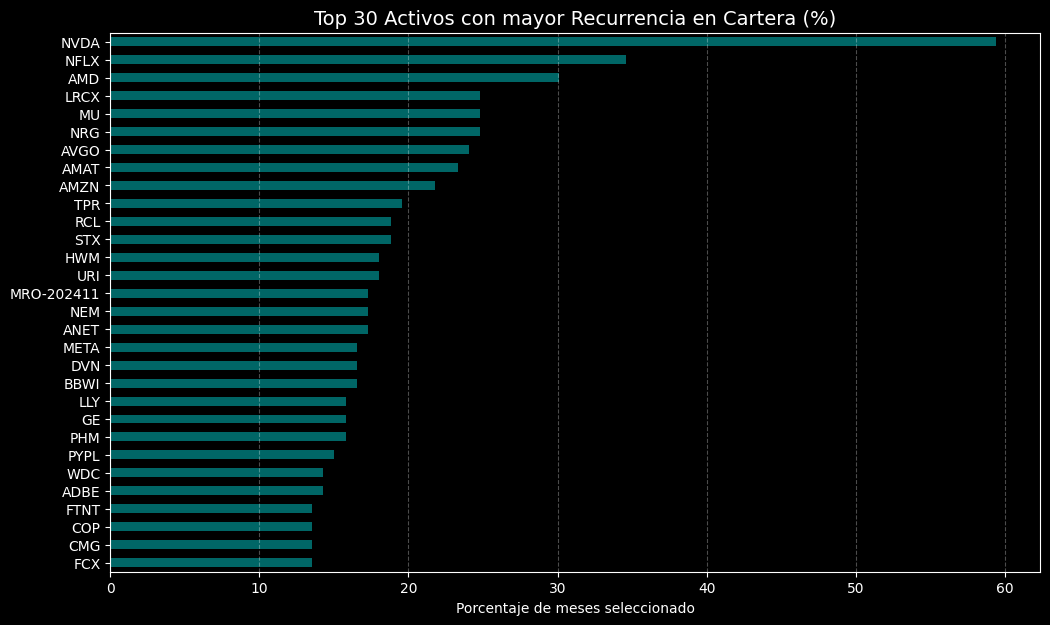

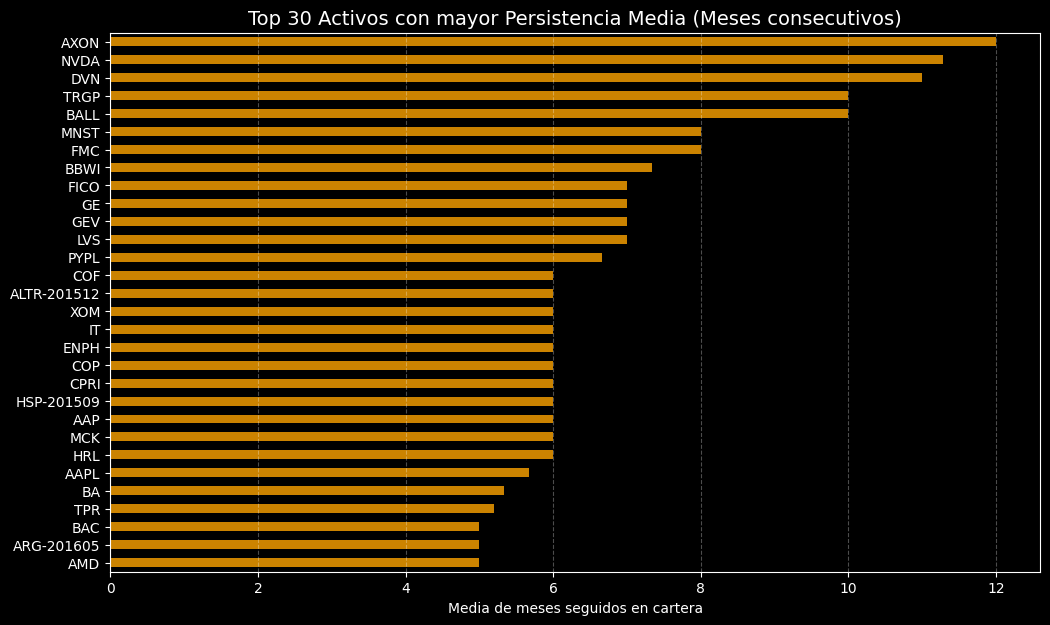


📊 Resumen de los 15 activos líderes en frecuencia:
            Frecuencia (%)  Persistencia Media (Meses)  Score Momentum Medio
NVDA                 59.40                       11.29                  0.86
NFLX                 34.59                        3.54                  0.72
AMD                  30.08                        5.00                  0.06
NRG                  24.81                        4.71                  0.21
LRCX                 24.81                        3.00                  0.69
MU                   24.81                        4.71                  0.06
AVGO                 24.06                        2.91                  0.91
AMAT                 23.31                        2.82                  0.22
AMZN                 21.80                        4.14                  0.59
TPR                  19.55                        5.20                  0.02
STX                  18.80                        3.57                  0.34
RCL                  18.

In [ ]:
# Estadísticas del Universo de Selección
# Filtramos para trabajar solo con activos que han estado en cartera alguna vez
selected_mask = weights_df.sum() > 0
active_weights = weights_df.loc[:, selected_mask]

n_selected = selected_mask.sum()
n_total = weights_df.shape[1]

print(f"🌍 Cobertura del Universo S&P 500:")
print(f" - Tickers totales analizados: {n_total}")
print(f" - Tickers seleccionados al menos una vez en el Top 20: {n_selected} ({n_selected/n_total:.1%})")

# A. Frecuencia de Selección (% de tiempo en el Top 20)
selection_freq = (active_weights > 0).sum() / len(weights_df) * 100

plt.figure(figsize=(12, 7))
# Mostramos el Top 30 para no saturar el gráfico
top_frequent = selection_freq.sort_values(ascending=False).head(30)
top_frequent.sort_values().plot(kind='barh', color='teal', alpha=0.8)
plt.title('Top 30 Activos con mayor Recurrencia en Cartera (%)', fontsize=14)
plt.xlabel('Porcentaje de meses seleccionado')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.show()

# B. Persistencia (¿Cuánto tiempo permanece un activo una vez entra?)
def calc_avg_duration(series):
    in_portfolio = series > 0
    if not in_portfolio.any(): return 0
    # Agrupamos periodos consecutivos
    groups = (in_portfolio != in_portfolio.shift()).cumsum()
    durations = in_portfolio.groupby(groups).sum()
    return durations[durations > 0].mean()

avg_durations = active_weights.apply(calc_avg_duration)

plt.figure(figsize=(12, 7))
top_persistence = avg_durations.sort_values(ascending=False).head(30)
top_persistence.sort_values().plot(kind='barh', color='orange', alpha=0.8)
plt.title('Top 30 Activos con mayor Persistencia Media (Meses consecutivos)', fontsize=14)
plt.xlabel('Media de meses seguidos en cartera')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.show()

print("\n📊 Resumen de los 15 activos líderes en frecuencia:")
summary_stats = pd.DataFrame({
    'Frecuencia (%)': selection_freq,
    'Persistencia Media (Meses)': avg_durations,
    'Score Momentum Medio': score_final.loc[:, selected_mask].mean()
}).sort_values(by='Frecuencia (%)', ascending=False)
print(summary_stats.head(15).round(2))

### 4. Situación Actual de la Cartera
Mostramos en qué activos deberíamos estar invertidos según el último cálculo disponible.

In [ ]:

# --- REBALANCEO ACTUAL ---
# La señal de hoy se basa en el último mes CERRADO disponible.
last_date_available = weights_df.index[-1]
last_weights = weights_df.loc[last_date_available]
current_portfolio = last_weights[last_weights > 0]

print(f"🏛️ INSTRUCCIONES DE REBALANCEO ({last_date_available.strftime('%d/%m/%Y')} - Cierre de Mes)")
print("="*60)
for ticker, weight in current_portfolio.items():
    print(f" COMPRAR/MANTENER -> {ticker}: {weight*100:.1f}%")
print("="*60)


🏛️ INSTRUCCIONES DE REBALANCEO (30/01/2026 - Cierre de Mes)
 COMPRAR/MANTENER -> ALB: 5.0%
 COMPRAR/MANTENER -> AMD: 5.0%
 COMPRAR/MANTENER -> APH: 5.0%
 COMPRAR/MANTENER -> CHRW: 5.0%
 COMPRAR/MANTENER -> EXPE: 5.0%
 COMPRAR/MANTENER -> GLW: 5.0%
 COMPRAR/MANTENER -> GM: 5.0%
 COMPRAR/MANTENER -> GOOGL: 5.0%
 COMPRAR/MANTENER -> HII: 5.0%
 COMPRAR/MANTENER -> INTC: 5.0%
 COMPRAR/MANTENER -> IVZ: 5.0%
 COMPRAR/MANTENER -> LRCX: 5.0%
 COMPRAR/MANTENER -> MU: 5.0%
 COMPRAR/MANTENER -> NEM: 5.0%
 COMPRAR/MANTENER -> PLTR: 5.0%
 COMPRAR/MANTENER -> STX: 5.0%
 COMPRAR/MANTENER -> TER: 5.0%
 COMPRAR/MANTENER -> TPR: 5.0%
 COMPRAR/MANTENER -> WBD: 5.0%
 COMPRAR/MANTENER -> WDC: 5.0%
